# 📰 News Topic Classification using TF-IDF and Linear Support Vector Machine

## 1. Project Initialization

### Objective

Tahap ini bertujuan untuk menyiapkan lingkungan kerja (environment) yang akan digunakan selama proses penelitian, termasuk instalasi library, import package, serta konfigurasi dasar notebook.

---

### Project Information

| Item | Description |
|------|-------------|
| Project | News Topic Classification |
| Dataset | Indonesian News Title Dataset |
| Source | https://www.kaggle.com/datasets/ibamibrahim/indonesian-news-title |
| Input Feature | News Title |
| Target Label | News Category |
| Number of Classes | 9 |
| Categories | finance, food, health, hot, inet, news, oto, sport, travel |
| Feature Extraction | TF-IDF (Unigram & Bigram) |
| Classification Model | Linear Support Vector Machine (Linear SVM) |
| Development Environment | Google Colab |
| Model Deployment | Python (.py) / Streamlit |

In [ ]:
# ==========================================================
# 1.1 Environment Setup
# ==========================================================

# Install required libraries
!pip -q install Sastrawi
!pip -q install wordcloud

# ==========================================================
# Import Standard Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import os
import re
import string
import numpy as np
import pandas as pd

# ==========================================================
# Data Visualization
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

sns.set_theme(style="whitegrid")

# ==========================================================
# Natural Language Processing
# ==========================================================

import nltk

nltk.download("punkt")
nltk.download("stopwords")

# ==========================================================
# Reproducibility
# ==========================================================

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("="*60)
print("PROJECT INITIALIZATION COMPLETED")
print("="*60)

PROJECT INITIALIZATION COMPLETED


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# 📂 2. Dataset Understanding

## Objective

Tahap ini bertujuan untuk memuat dataset dari Google Drive dan memahami struktur dataset sebelum dilakukan analisis lebih lanjut.

Aktivitas yang dilakukan meliputi:

- Menghubungkan Google Colab dengan Google Drive
- Memuat dataset
- Menampilkan informasi dasar dataset
- Mengidentifikasi fitur (feature) dan target (label)

In [ ]:
# ==========================================================
# 2.1 Load Dataset
# ==========================================================

from google.colab import drive

# Mount Google Drive
drive.mount("/content/drive")

# Dataset Path
DATASET_PATH = "/content/drive/MyDrive/SEMESTER 6/NLP/Dataset/indonesian-news-title.csv"

# Read Dataset
df = pd.read_csv(DATASET_PATH)

print("=" * 60)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 60)
print(f"Dataset Shape : {df.shape}")

Mounted at /content/drive
DATASET LOADED SUCCESSFULLY
Dataset Shape : (91017, 4)


In [ ]:
# ==========================================================
# 2.2 Dataset Overview
# ==========================================================

# Display first five records
display(df.head())

print("\n")

# Dataset Information
print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

df.info()

print("\n")

# Dataset Summary
overview = pd.DataFrame({

    "Description":[
        "Total Samples",
        "Total Features",
        "Feature Column",
        "Target Column",
        "Number of Categories"
    ],

    "Value":[
        len(df),
        len(df.columns),
        "title",
        "category",
        df["category"].nunique()
    ]

})

display(overview)

print("\n")

print("=" * 60)
print("COLUMN NAMES")
print("=" * 60)

display(pd.DataFrame(df.columns, columns=["Columns"]))

,date,url,title,category
0,02/26/2020,https://finance.detik.com/berita-ekonomi-bisni...,Kemnaker Awasi TKA di Meikarta,finance
1,02/26/2020,https://finance.detik.com/berita-ekonomi-bisni...,BNI Digitalkan BNI Java Jazz 2020,finance
2,02/26/2020,https://finance.detik.com/berita-ekonomi-bisni...,"Terbang ke Australia, Edhy Prabowo Mau Genjot ...",finance
3,02/26/2020,https://finance.detik.com/moneter/d-4916133/oj...,OJK Siapkan Stimulus Ekonomi Antisipasi Dampak...,finance
4,02/26/2020,https://finance.detik.com/berita-ekonomi-bisni...,Saran Buat Anies-RK yang Mangkir Rapat Banjir ...,finance




DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91017 entries, 0 to 91016
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   date      91017 non-null  object
 1   url       91017 non-null  object
 2   title     91017 non-null  object
 3   category  91017 non-null  object
dtypes: object(4)
memory usage: 2.8+ MB




,Description,Value
0,Total Samples,91017
1,Total Features,4
2,Feature Column,title
3,Target Column,category
4,Number of Categories,9




COLUMN NAMES


,Columns
0,date
1,url
2,title
3,category


# 📊 3. Exploratory Data Analysis (EDA)

## Objective

Tahap ini bertujuan untuk memahami karakteristik dan kualitas dataset sebelum dilakukan proses data preparation dan text preprocessing.

Analisis yang dilakukan meliputi:

- Dataset Quality Assessment
- Category Distribution
- News Title Length Analysis
- Exploratory Data Summary

In [ ]:
# ==========================================================
# 3.1 Dataset Quality Assessment
# ==========================================================

# Missing Values
missing_values = df.isnull().sum()

# Duplicate Rows
duplicate_rows = df.duplicated().sum()

# Duplicate URLs
duplicate_urls = df.duplicated(subset=["url"]).sum()

# Duplicate Titles
duplicate_titles = df.duplicated(subset=["title"]).sum()

# News Title Length
title_length = df["title"].str.split().str.len()

summary = pd.DataFrame({

    "Description":[
        "Dataset Shape",
        "Missing Values",
        "Duplicate Rows",
        "Duplicate URLs",
        "Duplicate Titles",
        "Average Title Length",
        "Maximum Title Length",
        "Minimum Title Length"
    ],

    "Value":[
        str(df.shape),
        missing_values.sum(),
        duplicate_rows,
        duplicate_urls,
        duplicate_titles,
        round(title_length.mean(),2),
        title_length.max(),
        title_length.min()
    ]

})

print("="*60)
print("DATASET QUALITY")
print("="*60)

display(summary)

DATASET QUALITY


,Description,Value
0,Dataset Shape,"(91017, 4)"
1,Missing Values,0
2,Duplicate Rows,8
3,Duplicate URLs,5639
4,Duplicate Titles,126
5,Average Title Length,9.28
6,Maximum Title Length,20
7,Minimum Title Length,1


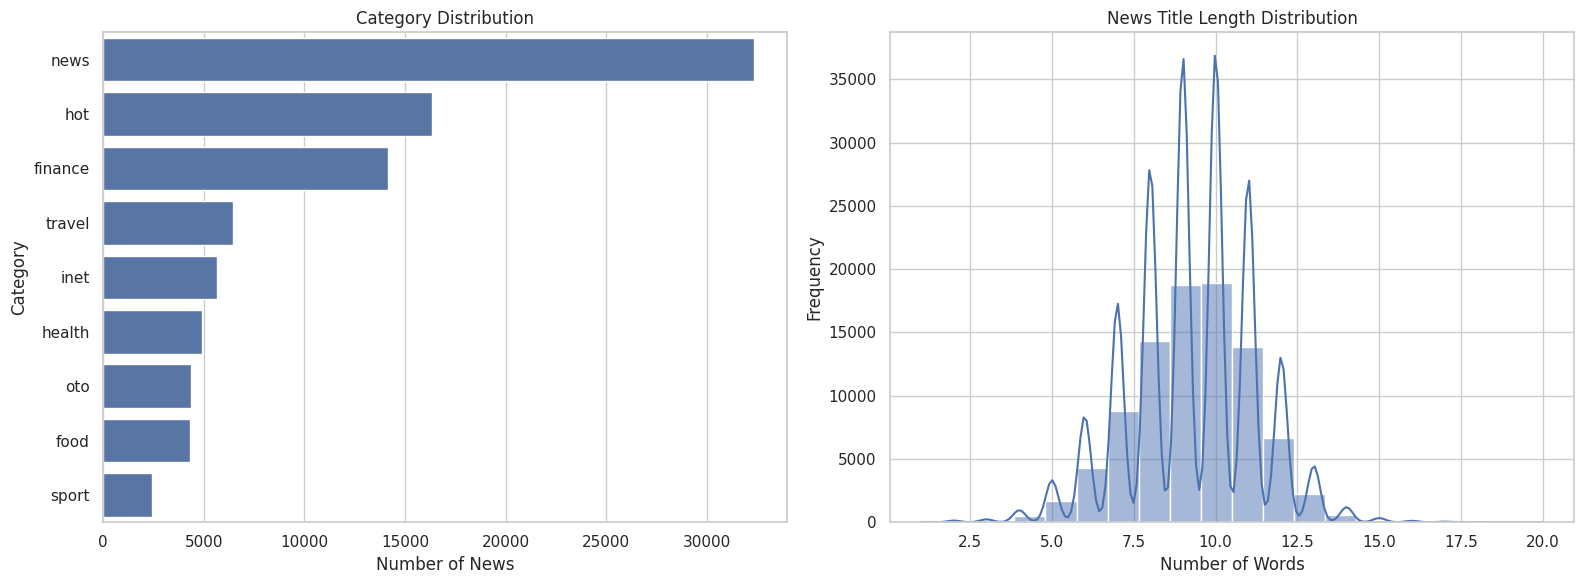

In [ ]:
# ==========================================================
# 3.2 Dataset Visualization
# ==========================================================

fig, axes = plt.subplots(1, 2, figsize=(16,6))

# ----------------------------------------------------------
# Category Distribution
# ----------------------------------------------------------

category_count = df["category"].value_counts()

sns.barplot(
    x=category_count.values,
    y=category_count.index,
    ax=axes[0]
)

axes[0].set_title("Category Distribution")
axes[0].set_xlabel("Number of News")
axes[0].set_ylabel("Category")

# ----------------------------------------------------------
# Title Length Distribution
# ----------------------------------------------------------

sns.histplot(
    title_length,
    bins=20,
    kde=True,
    ax=axes[1]
)

axes[1].set_title("News Title Length Distribution")
axes[1].set_xlabel("Number of Words")
axes[1].set_ylabel("Frequency")

plt.tight_layout()

plt.show()

In [ ]:
# ==========================================================
# 3.3 Exploratory Data Summary
# ==========================================================

print("="*60)
print("CATEGORY DISTRIBUTION")
print("="*60)

display(
    pd.DataFrame({
        "Count": df["category"].value_counts(),
        "Percentage (%)":
        round(df["category"].value_counts(normalize=True)*100,2)
    })
)

print("\n")

print("="*60)
print("OBSERVATION")
print("="*60)

print("""
1. The dataset contains 9 news categories.
2. No missing values were found.
3. Duplicate rows exist and will be handled during Data Preparation.
4. Duplicate URLs require further investigation.
5. Duplicate titles are retained because identical titles may represent different news articles.
6. The dataset is imbalanced, with the 'news' category containing substantially more samples than 'sport'.
7. News titles are generally short, making TF-IDF an appropriate feature extraction method.
""")

CATEGORY DISTRIBUTION


,Count,Percentage (%)
category,,
news,32360,35.55
hot,16330,17.94
finance,14168,15.57
travel,6466,7.10
inet,5640,6.20
health,4919,5.40
oto,4383,4.82
food,4315,4.74
sport,2436,2.68




OBSERVATION

1. The dataset contains 9 news categories.
2. No missing values were found.
3. Duplicate rows exist and will be handled during Data Preparation.
4. Duplicate URLs require further investigation.
5. Duplicate titles are retained because identical titles may represent different news articles.
6. The dataset is imbalanced, with the 'news' category containing substantially more samples than 'sport'.
7. News titles are generally short, making TF-IDF an appropriate feature extraction method.



# 4. Data Preparation

## Tujuan

Tahap ini bertujuan untuk memastikan kualitas dataset sebelum digunakan pada proses pelatihan model **IndoBERT**.

Pada tahap ini dilakukan pemeriksaan dan perbaikan kualitas data tanpa mengubah struktur linguistik teks. Hal ini penting karena model **IndoBERT** memanfaatkan konteks kalimat secara utuh melalui tokenizer bawaan.

## Tahapan

Tahapan yang dilakukan meliputi:

1. Menghapus baris yang memiliki nilai kosong (missing values).
2. Menghapus baris yang identik (duplicate rows).
3. Menganalisis duplicate URL.
4. Menganalisis duplicate title.
5. Membentuk working dataset yang siap diproses pada tahap berikutnya.

Catatan:

- Duplicate URL tidak dihapus secara otomatis karena dapat berasal dari proses scraping.
- Duplicate title tetap dipertahankan karena judul yang sama dapat muncul pada waktu atau konteks yang berbeda.

## 4.1 Data Preparation

In [ ]:
# ==========================================================
# 4.1 Data Preparation
# ==========================================================
print("=" * 60)
print("DATA PREPARATION")
print("=" * 60)

# Dataset Shape
print(f"Original Dataset Shape : {df.shape}")

# Remove Missing Values
df = df.dropna()

# Remove Exact Duplicate Rows
df = df.drop_duplicates()

print(f"Working Dataset Shape  : {df.shape}")

DATA PREPARATION
Original Dataset Shape : (91017, 4)
Working Dataset Shape  : (91009, 4)


#### Analisis Duplicate Data

Tahap ini bertujuan untuk mengidentifikasi keberadaan duplicate URL dan duplicate title.

Analisis ini dilakukan sebagai bahan evaluasi kualitas dataset. Duplicate tersebut **tidak dihapus secara otomatis** karena masih berpotensi merepresentasikan berita yang berbeda.

## 4.2 Duplicate Analysis

In [ ]:
# ==========================================================
# Duplicate Analysis
# ==========================================================

# Ensure df contains the 'url' column for analysis.
# If 'df' was modified to remove 'url' earlier,
# we recreate it from df_original to ensure 'url' is present.
# This assumes df_original holds the initial dataset with all columns.
if 'url' not in df.columns and 'df_original' in globals():
    df = df_original.copy()
    # Re-apply previous data preparation steps if necessary
    df = df.dropna()
    df = df.drop_duplicates()

duplicate_url = df.duplicated(subset=["url"]).sum()
duplicate_title = df.duplicated(subset=["title"]).sum()

summary = pd.DataFrame({

    "Description":[

        "Total Samples",

        "Missing Values",

        "Duplicate Rows",

        "Duplicate URLs",

        "Duplicate Titles"

    ],

    "Value":[

        len(df),

        df.isnull().sum().sum(),

        df.duplicated().sum(),

        duplicate_url,

        duplicate_title

    ]

})

display(summary)

,Description,Value
0,Total Samples,91009
1,Missing Values,0
2,Duplicate Rows,0
3,Duplicate URLs,5631
4,Duplicate Titles,118


#### Contoh Duplicate Data

Bagian ini menampilkan beberapa contoh duplicate URL dan duplicate title untuk membantu proses inspeksi kualitas data.

## 4.3 Display Duplicate Samples

In [ ]:
# ==========================================================
# Display Duplicate Samples
# ==========================================================

if duplicate_url > 0:

    print("Duplicate URL Samples")

    display(

        df[df.duplicated(subset=["url"], keep=False)]
        .sort_values("url")
        .head(5)

    )

print()

if duplicate_title > 0:

    print("Duplicate Title Samples")

    display(

        df[df.duplicated(subset=["title"], keep=False)]
        .sort_values("title")
        .head(5)

    )

Duplicate URL Samples


,date,url,title,category
39732,05/14/2020,#,Google Sampai Kekurangan Laptop Karena Work Fr...,inet
43498,05/04/2020,#,Startup Ini Berkembang Pesat Selama Pandemi Co...,inet
43497,05/04/2020,#,"Beredar Aneka Situs Cek Email Diretas, Amankah...",inet
43496,05/04/2020,#,3 Game Multiplayer Android yang Seru Buat Ngab...,inet
43495,05/04/2020,#,Kominfo Selidiki Kebocoran Data Pengguna Tokop...,inet



Duplicate Title Samples


,date,url,title,category
36985,04/24/2020,https://hot.detik.com/tv-news/d-4989895/the-ex...,'The Expendables 3' dan 'A Good Man' Tayang di...,hot
36982,04/24/2020,https://hot.detik.com/tv-news/d-4989920/the-ex...,'The Expendables 3' dan 'A Good Man' Tayang di...,hot
55232,03/06/2020,https://news.detik.com/berita/d-4927819/1-wni-...,"1 WNI ABK Diamond Princess Dicurigai COVID-19,...",news
18763,03/06/2020,https://health.detik.com/berita-detikhealth/d-...,"1 WNI ABK Diamond Princess Dicurigai COVID-19,...",health
70942,03/04/2020,https://news.detik.com/berita/d-4925818/11-ora...,11 Orang Kontak Langsung dengan WN Jepang di B...,news


## Kesimpulan Data Preparation

Berdasarkan hasil pemeriksaan, dataset telah memenuhi kebutuhan awal untuk proses pelatihan model.

Perbaikan yang dilakukan hanya mencakup penghapusan missing value dan duplicate rows, sedangkan duplicate URL dan duplicate title dipertahankan untuk menjaga karakteristik asli dataset.

## 4.4 Final Data Preparation Summary


In [ ]:
# ==========================================================
# Final Data Preparation Summary
# ==========================================================

summary = pd.DataFrame({

    "Description":[

        "Working Dataset",

        "Number of Categories",

        "Missing Values",

        "Duplicate Rows"

    ],

    "Value":[

        len(df),

        df["category"].nunique(),

        df.isnull().sum().sum(),

        df.duplicated().sum()

    ]

})

display(summary)

,Description,Value
0,Working Dataset,91009
1,Number of Categories,9
2,Missing Values,0
3,Duplicate Rows,0


# 5. Basic Text Cleaning

## Tujuan

Tahap ini bertujuan untuk melakukan pembersihan dasar pada teks sebelum diproses menggunakan model **IndoBERT**.

Berbeda dengan pendekatan Machine Learning tradisional yang memerlukan tokenisasi, stopword removal, dan stemming, model **IndoBERT** menggunakan tokenizer bawaan sehingga struktur kalimat perlu dipertahankan semaksimal mungkin.

Oleh karena itu, proses pembersihan pada penelitian ini hanya mencakup normalisasi dasar tanpa menghilangkan informasi linguistik yang diperlukan oleh model.

## Tahapan Pembersihan

Proses yang dilakukan meliputi:

1. Menangani nilai kosong (missing value).
2. Mengubah seluruh huruf menjadi huruf kecil (case folding).
3. Menghapus URL.
4. Menghapus tag HTML apabila ada.
5. Menghapus karakter whitespace berlebih.
6. Menghapus spasi di awal dan akhir kalimat (trim whitespace).

Tahap ini **tidak melakukan**:

- Tokenisasi
- Stopword Removal
- Stemming
- Lemmatization

karena seluruh proses tokenisasi akan dilakukan oleh tokenizer **IndoBERT** pada tahap berikutnya.

## 5.1 Basic Cleaning Function

In [ ]:
# ==========================================================
# BASIC TEXT CLEANING FUNCTION
# ==========================================================

import re
import pandas as pd


def basic_text_cleaning(text):

    if pd.isna(text):
        return ""

    text = str(text)

    # Case Folding
    text = text.lower()

    # Remove URL
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove HTML Tags
    text = re.sub(r"<.*?>", "", text)

    # Remove Extra Whitespaces
    text = re.sub(r"\s+", " ", text)

    # Trim
    text = text.strip()

    return text

## Menerapkan Basic Text Cleaning

Fungsi `basic_text_cleaning()` diterapkan pada seluruh kolom **title** untuk menghasilkan kolom baru bernama **clean_text**.

Kolom ini akan digunakan sebagai masukan pada proses tokenisasi menggunakan tokenizer bawaan **IndoBERT**.

## 5.2 Apply Cleaning

In [ ]:
# ==========================================================
# APPLY BASIC TEXT CLEANING
# ==========================================================

df["clean_text"] = df["title"].apply(basic_text_cleaning)

print("=" * 60)
print("BASIC TEXT CLEANING")
print("=" * 60)

print("✔ Basic cleaning completed.")
print()

display(
    df[["title", "clean_text", "category"]].head(10)
)

BASIC TEXT CLEANING
✔ Basic cleaning completed.



,title,clean_text,category
0,Kemnaker Awasi TKA di Meikarta,kemnaker awasi tka di meikarta,finance
1,BNI Digitalkan BNI Java Jazz 2020,bni digitalkan bni java jazz 2020,finance
2,"Terbang ke Australia, Edhy Prabowo Mau Genjot ...","terbang ke australia, edhy prabowo mau genjot ...",finance
3,OJK Siapkan Stimulus Ekonomi Antisipasi Dampak...,ojk siapkan stimulus ekonomi antisipasi dampak...,finance
4,Saran Buat Anies-RK yang Mangkir Rapat Banjir ...,saran buat anies-rk yang mangkir rapat banjir ...,finance
5,RI Bakal Punya Destinasi Wisata Sejarah Islam ...,ri bakal punya destinasi wisata sejarah islam ...,finance
6,Cara Biar Nggak Tertipu Travel Umrah Abal-abal...,cara biar nggak tertipu travel umrah abal-abal...,finance
7,"DPR Kritik Cara Anies Atasi Banjir, Pesan Kera...","dpr kritik cara anies atasi banjir, pesan kera...",finance
8,Jadi Korban Gagal Bayar Asuransi? Bisa Mengadu...,jadi korban gagal bayar asuransi? bisa mengadu...,finance
9,Erick Thohir: BUMN Bukan Badan Usaha Milik Nen...,erick thohir: bumn bukan badan usaha milik nen...,finance


## Hasil Basic Text Cleaning

Bagian ini menampilkan beberapa contoh data sebelum dan sesudah proses pembersihan teks untuk memastikan proses cleaning telah berjalan dengan benar.

## 5.3 Display Result

In [ ]:
# ==========================================================
# CLEANING VERIFICATION
# ==========================================================

summary = pd.DataFrame({

    "Description":[

        "Total Samples",

        "Missing clean_text",

        "Average Title Length",

        "Average Clean Text Length"

    ],

    "Value":[

        len(df),

        df["clean_text"].isnull().sum(),

        df["title"].str.split().str.len().mean(),

        df["clean_text"].str.split().str.len().mean()

    ]

})

display(summary)

,Description,Value
0,Total Samples,91009.000000
1,Missing clean_text,0.000000
2,Average Title Length,9.276203
3,Average Clean Text Length,9.276181


# 6. Label Encoding & Dataset Preparation

## Tujuan

Tahap ini bertujuan untuk menyiapkan dataset agar dapat digunakan pada proses pelatihan model **IndoBERT**.

Pada tahap ini dilakukan proses pengubahan label kategori dari bentuk teks menjadi representasi numerik menggunakan **LabelEncoder**. Model klasifikasi hanya dapat memproses label dalam bentuk bilangan bulat.

Selain itu, tahap ini juga menyiapkan dataset akhir yang terdiri atas:

- `clean_text` sebagai fitur (input)
- `label` sebagai target klasifikasi

Dataset hasil tahap ini akan digunakan pada proses tokenisasi menggunakan **IndoBERT Tokenizer** pada tahap berikutnya.

## 6.1 Label Encoding

In [ ]:
# ==========================================================
# LABEL ENCODING
# ==========================================================

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["category"])

print("=" * 60)
print("LABEL ENCODING")
print("=" * 60)

print(f"Total Classes : {len(label_encoder.classes_)}")
print()

display(
    pd.DataFrame({
        "Category": label_encoder.classes_,
        "Encoded Label": range(len(label_encoder.classes_))
    })
)

LABEL ENCODING
Total Classes : 9



,Category,Encoded Label
0,finance,0
1,food,1
2,health,2
3,hot,3
4,inet,4
5,news,5
6,oto,6
7,sport,7
8,travel,8


## Menyiapkan Dataset Akhir

Setelah proses label encoding selesai, dataset disusun ulang agar hanya berisi atribut yang dibutuhkan pada proses pelatihan model.

Kolom yang digunakan adalah:

- `clean_text` sebagai input model.
- `label` sebagai target klasifikasi.

## 6.2 Final Dataset

In [ ]:
dataset = df[["clean_text", "label"]].copy()

display(dataset.head())

,clean_text,label
0,kemnaker awasi tka di meikarta,0
1,bni digitalkan bni java jazz 2020,0
2,"terbang ke australia, edhy prabowo mau genjot ...",0
3,ojk siapkan stimulus ekonomi antisipasi dampak...,0
4,saran buat anies-rk yang mangkir rapat banjir ...,0


## 6.3 Dataset Summary

In [ ]:
# ==========================================================
# DATASET SUMMARY
# ==========================================================

summary = pd.DataFrame({

    "Description":[

        "Total Samples",

        "Number of Classes",

        "Input Feature",

        "Target Label"

    ],

    "Value":[

        len(dataset),

        dataset["label"].nunique(),

        "clean_text",

        "label"

    ]

})

display(summary)

,Description,Value
0,Total Samples,91009
1,Number of Classes,9
2,Input Feature,clean_text
3,Target Label,label


## Ringkasan Dataset

Tahap ini digunakan untuk memastikan dataset telah siap digunakan pada proses tokenisasi menggunakan **IndoBERT Tokenizer**.

# 7. Train, Validation, and Test Split

## Tujuan

Tahap ini bertujuan untuk membagi dataset menjadi tiga bagian, yaitu training set, validation set, dan testing set.

Pembagian data dilakukan menggunakan metode **Stratified Split** untuk mempertahankan proporsi setiap kategori berita pada masing-masing subset.

Proporsi pembagian data adalah:

- Training Set : 80%
- Validation Set : 10%
- Testing Set : 10%

Training set digunakan untuk proses fine-tuning model, validation set digunakan selama proses pelatihan untuk memilih model terbaik, sedangkan testing set digunakan untuk evaluasi akhir model.

## 7.1 Train Validation Test Split

**Teknik Stratified Split** digunakan untuk memastikan proporsi setiap kategori
berita sama di seluruh subset (train/validation/test). Ini penting karena dataset
memiliki ketidakseimbangan kelas (*class imbalance*), misalnya kategori *news*
jauh lebih banyak daripada *sport*.

**Proporsi:**
- Training Set (80%): digunakan untuk melatih model
- Validation Set (10%): digunakan untuk memilih hyperparameter terbaik
- Testing Set (10%): digunakan untuk evaluasi akhir (tidak pernah dilihat model)


In [ ]:

from sklearn.model_selection import train_test_split

# ==========================================================
# TRAIN VALIDATION TEST SPLIT
# ==========================================================

X = dataset["clean_text"]

y = dataset["label"]

# 80% Train | 20% Temporary
X_train, X_temp, y_train, y_temp = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

# 10% Validation | 10% Test
X_valid, X_test, y_valid, y_test = train_test_split(

    X_temp,

    y_temp,

    test_size=0.50,

    random_state=42,

    stratify=y_temp

)

## 7.2 Split Summary

In [ ]:
# ==========================================================
# Split Summary
# ==========================================================

summary = pd.DataFrame({

    "Dataset":[

        "Training",

        "Validation",

        "Testing"

    ],

    "Samples":[

        len(X_train),

        len(X_valid),

        len(X_test)

    ]

})

display(summary)

,Dataset,Samples
0,Training,72807
1,Validation,9101
2,Testing,9101


## 7.3 Class Distribution



In [ ]:
# ==========================================================
# Class Distribution
# ==========================================================

distribution = pd.DataFrame({

    "Train": y_train.value_counts().sort_index(),

    "Validation": y_valid.value_counts().sort_index(),

    "Test": y_test.value_counts().sort_index()

})

distribution.index = label_encoder.inverse_transform(distribution.index)

display(distribution)

,Train,Validation,Test
finance,11334,1417,1417
food,3452,431,432
health,3935,492,492
hot,13064,1633,1633
inet,4506,563,563
news,25888,3236,3236
oto,3506,439,438
sport,1949,243,244
travel,5173,647,646


# 8. Baseline Model: TF-IDF + Linear SVM

## Tujuan

Tahap ini bertujuan untuk membangun **model baseline** menggunakan pendekatan klasik:
TF-IDF (*Term Frequency-Inverse Document Frequency*) sebagai ekstraksi fitur dan
**Linear Support Vector Machine (Linear SVM)** sebagai classifier.

Model baseline ini akan menjadi **tolok ukur (baseline)** untuk membandingkan performa
model **IndoBERT** yang akan dilatih pada tahap selanjutnya.

### Konfigurasi Baseline

| Komponen | Detail |
|----------|--------|
| Feature Extraction | TF-IDF (Unigram & Bigram) |
| Classifier | Linear Support Vector Machine (LinearSVC) |
| Data Splitting | 80% Train, 10% Validation, 10% Test |

> **Catatan**: Model ini hanya menggunakan **training set** untuk pelatihan dan **testing set**
untuk evaluasi akhir. Validation set tidak digunakan pada baseline ini.


## 8.1 TF-IDF Vectorization

Tahap ini mengubah teks menjadi representasi numerik menggunakan TF-IDF.
Fitur yang digunakan adalah **unigram dan bigram** untuk menangkap informasi kata tunggal
maupun pasangan kata yang sering muncul bersamaan.

Parameter:
- `ngram_range=(1, 2)` → Unigram & Bigram
- `max_features=5000` → Maksimal 5000 fitur terbaik
- `sublinear_tf=True` → Menggunakan 1 + log(TF) untuk mengurangi dominasi kata sangat frequent


In [ ]:
# ==========================================================
# TF-IDF Vectorization
# ==========================================================

from sklearn.feature_extraction.text import TfidfVectorizer

print("=" * 60)
print("TF-IDF VECTORIZATION")
print("=" * 60)

# Initialize TF-IDF with unigram and bigram
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=5000,
    sublinear_tf=True
)

# Fit on training data, transform both train and test
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"Training set shape   : {X_train_tfidf.shape}")
print(f"Testing set shape    : {X_test_tfidf.shape}")
print(f"Vocabulary size      : {len(tfidf_vectorizer.vocabulary_)}")


TF-IDF VECTORIZATION
Training set shape   : (72807, 5000)
Testing set shape    : (9101, 5000)
Vocabulary size      : 5000


## 8.2 Train Linear SVM

Model **LinearSVC** dilatih menggunakan data training yang sudah di-vektorisasi.
Parameter `C` (regularization) diatur secara sederhana tanpa hyperparameter tuning,
karena tujuan utama adalah mendapatkan baseline yang wajar, bukan optimal.


In [ ]:
# ==========================================================
# Train Linear SVM
# ==========================================================

from sklearn.svm import LinearSVC

print("=" * 60)
print("LINEAR SVM TRAINING")
print("=" * 60)

svm_model = LinearSVC(
    C=1.0,
    random_state=RANDOM_STATE,
    max_iter=2000
)

print("Training Linear SVM...")
svm_model.fit(X_train_tfidf, y_train)
print("Training completed.")


LINEAR SVM TRAINING
Training Linear SVM...
Training completed.


## 8.3 Baseline Evaluation

Model baseline dievaluasi menggunakan **testing set**.
Metrik yang digunakan sama dengan evaluasi IndoBERT agar dapat dibandingkan:
- Accuracy
- Precision (Macro)
- Recall (Macro)
- F1-score (Macro)


BASELINE EVALUATION
Accuracy  : 0.8208
Precision : 0.7984
Recall    : 0.7599
F1-score  : 0.7776


CLASSIFICATION REPORT
              precision    recall  f1-score   support

     finance       0.80      0.82      0.81      1417
        food       0.84      0.78      0.81       432
      health       0.73      0.67      0.70       492
         hot       0.83      0.87      0.85      1633
        inet       0.76      0.69      0.72       563
        news       0.86      0.90      0.88      3236
         oto       0.81      0.71      0.76       438
       sport       0.82      0.69      0.75       244
      travel       0.72      0.71      0.72       646

    accuracy                           0.82      9101
   macro avg       0.80      0.76      0.78      9101
weighted avg       0.82      0.82      0.82      9101

CONFUSION MATRIX


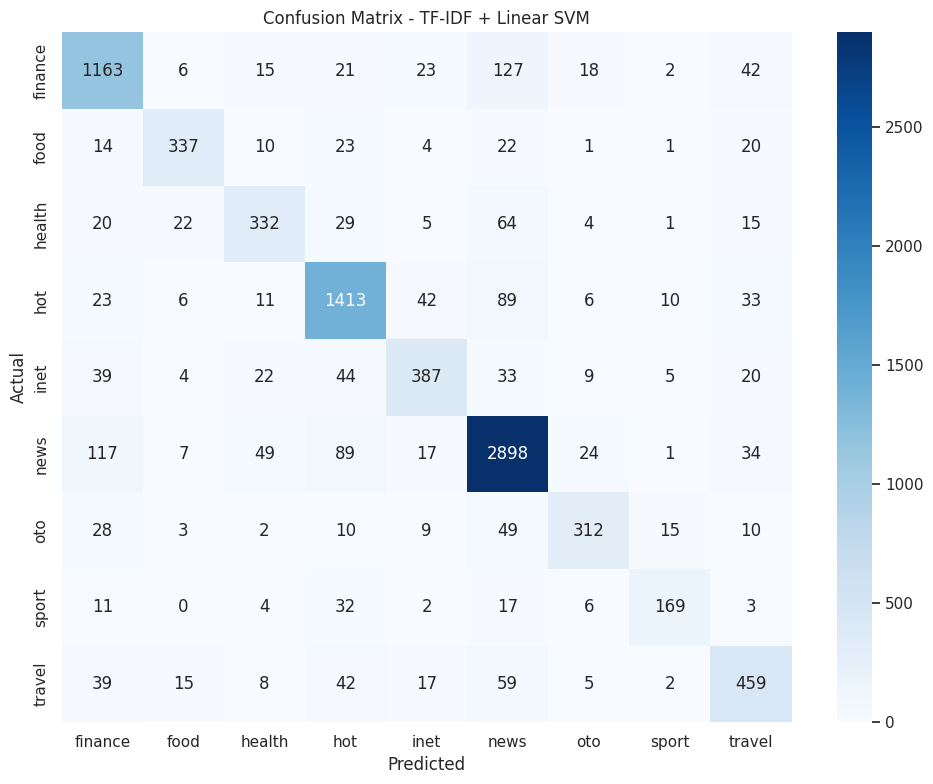

In [ ]:
# ==========================================================
# Baseline Evaluation
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 60)
print("BASELINE EVALUATION")
print("=" * 60)

# Predict
y_pred = svm_model.predict(X_test_tfidf)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, y_pred, average="macro"
)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

print("\n")
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

# Decode labels for readable report
target_names = label_encoder.classes_
print(classification_report(
    y_test, y_pred,
    target_names=target_names
))

# Confusion Matrix
print("=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names
)
plt.title("Confusion Matrix - TF-IDF + Linear SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


## 8.4 Baseline Results Summary

Hasil evaluasi model baseline (TF-IDF + Linear SVM) akan dibandingkan dengan
hasil fine-tuning IndoBERT pada bagian **Model Comparison** nanti.


In [ ]:
# ==========================================================
# Baseline Summary
# ==========================================================

baseline_results = {
    "Model": "TF-IDF + Linear SVM",
    "Accuracy": round(accuracy, 4),
    "Precision (Macro)": round(precision, 4),
    "Recall (Macro)": round(recall, 4),
    "F1-score (Macro)": round(f1, 4)
}

print("=" * 60)
print("BASELINE RESULTS")
print("=" * 60)

for key, val in baseline_results.items():
    print(f"{key:20s} : {val}")


BASELINE RESULTS
Model                : TF-IDF + Linear SVM
Accuracy             : 0.8208
Precision (Macro)    : 0.7984
Recall (Macro)       : 0.7599
F1-score (Macro)     : 0.7776


# 9. IndoBERT Tokenization

## Tujuan

Tahap ini bertujuan untuk mengubah teks hasil **Basic Text Cleaning** menjadi representasi numerik yang dapat diproses oleh model **IndoBERT**.

Tokenisasi dilakukan menggunakan tokenizer bawaan dari model pretrained:

**indobenchmark/indobert-base-p1**

Tokenizer akan menghasilkan beberapa komponen penting, antara lain:

- `input_ids`
- `attention_mask`

Representasi tersebut akan digunakan sebagai input pada proses fine-tuning model pada tahap berikutnya.

## Konfigurasi Tokenizer

Parameter yang digunakan pada penelitian ini adalah:

- **padding** = `"max_length"`
- **truncation** = `True`
- **max_length** = `64`

Nilai `max_length = 64` dipilih karena dataset yang digunakan berupa **judul berita** yang memiliki panjang kalimat relatif pendek.

## 9.1 Load Tokenizer

**Tokenizer** adalah komponen yang mengubah teks menjadi representasi numerik
berupa token ID yang dapat diproses oleh model Transformer.

**IndoBERT** menggunakan `WordPiece Tokenizer` yang memecah kata menjadi sub-kata
(*subword*). Contoh: kata "menyelesaikan" bisa dipecah menjadi ["menye", "##lesaikan"].
Pendekatan ini memungkinkan model menangani kata-kata yang tidak dikenal (*out-of-vocabulary*).

Model yang digunakan: **indobenchmark/indobert-base-p1** — pretrained pada bahasa Indonesia.


In [ ]:
# ==========================================================
# Load INDOBERT Tokenizer
# ==========================================================

from transformers import AutoTokenizer

MODEL_NAME = "indobenchmark/indobert-base-p1"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("=" * 60)
print("INDOBERT TOKENIZER")
print("=" * 60)

print(f"Pretrained Model : {MODEL_NAME}")
print("Tokenizer loaded successfully.")


config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

INDOBERT TOKENIZER
Pretrained Model : indobenchmark/indobert-base-p1
Tokenizer loaded successfully.


## Tokenisasi Dataset

Proses tokenisasi dilakukan secara terpisah pada dataset:

- Training
- Validation
- Testing

Pendekatan ini mengikuti praktik yang umum digunakan pada proses fine-tuning model Transformer sehingga setiap subset data diproses secara independen.

## 9.2 Tokenization Function

Fungsi `tokenize_text()` digunakan untuk mengubah teks menjadi tensor yang siap
diproses oleh model IndoBERT.

**Parameter Tokenisasi:**
- `padding="max_length"` : semua kalimat dipadding ke panjang yang sama (64 token)
- `truncation=True` : kalimat lebih dari 64 token akan dipotong
- `max_length=64` : panjang maksimal 64 token, sesuai dengan rata-rata panjang
  judul berita yang relatif pendek (~9 kata)
- `return_tensors="pt"` : output dalam format PyTorch tensor

**Output Tokenizer:**
- `input_ids` : representasi numerik setiap token
- `attention_mask` : mask yang memberitahu model token mana yang asli (1) vs padding (0)

> **Attention Mask** : mekanisme yang memberi tahu model bagian mana dari input yang
> harus "diperhatikan". Token padding (0) diabaikan, sehingga model hanya fokus pada
> token yang memiliki informasi.


In [ ]:
# ==========================================================
# TOKENIZATION FUNCTION
# ==========================================================

def tokenize_text(texts):

    return tokenizer(

        texts.tolist(),

        padding="max_length",

        truncation=True,

        max_length=64,

        return_tensors="pt"

    )

## 9.3 Train-Validation-Test Split

Proses tokenisasi dilakukan secara terpisah pada masing-masing subset data
(training, validation, testing) untuk efisiensi memori.

Setiap subset akan menghasilkan:
- `train_encodings` : tokenisasi data training (72.807 sampel)
- `valid_encodings` : tokenisasi data validasi (9.101 sampel)
- `test_encodings` : tokenisasi data testing (9.101 sampel)

Masing-masing encoding berisi `input_ids` dan `attention_mask` dalam bentuk tensor
dengan ukuran `(n_samples, 64)`.


In [ ]:
# ==========================================================
# TOKENIZE DATASET
# ==========================================================

# NOTE: X_train, X_valid, X_test should be pandas Series of strings from the dataset's 'clean_text' column.
# This cell assumes a previous step has already performed the train-validation-test split.
# The `tokenize_text` function expects `texts.tolist()`, so X_train, X_valid, X_test must be Series or lists of strings.


# Ensure the split variables are defined before proceeding
if 'X_train' not in globals() or 'X_valid' not in globals() or 'X_test' not in globals():
    raise NameError("Training, validation, and test sets (X_train, X_valid, X_test) are not defined. Please run the data splitting cell.")

train_encodings = tokenize_text(X_train)

valid_encodings = tokenize_text(X_valid)

test_encodings = tokenize_text(X_test)

print("=" * 60)
print("TOKENIZATION COMPLETED")
print("=" * 60)

print("Training Set    :", train_encodings["input_ids"].shape)
print("Validation Set  :", valid_encodings["input_ids"].shape)
print("Testing Set     :", test_encodings["input_ids"].shape)


TOKENIZATION COMPLETED
Training Set    : torch.Size([72807, 64])
Validation Set  : torch.Size([9101, 64])
Testing Set     : torch.Size([9101, 64])


## 9.4 Verification

Tahap ini bertujuan untuk memastikan bahwa proses tokenisasi telah menghasilkan representasi numerik yang sesuai.

Informasi yang ditampilkan meliputi:

- Ukuran tensor
- Input IDs
- Attention Mask

In [ ]:
# ==========================================================
# TOKENIZATION VERIFICATION
# ==========================================================

print("=" * 60)
print("TOKENIZATION VERIFICATION")
print("=" * 60)

print("Input IDs Shape")

print(train_encodings["input_ids"].shape)

print()

print("Attention Mask Shape")

print(train_encodings["attention_mask"].shape)

TOKENIZATION VERIFICATION
Input IDs Shape
torch.Size([72807, 64])

Attention Mask Shape
torch.Size([72807, 64])


### Contoh Hasil Tokenisasi

Bagian ini menampilkan contoh token hasil proses tokenisasi menggunakan tokenizer **IndoBERT**.

Contoh ini digunakan untuk memperlihatkan bagaimana sebuah judul berita diubah menjadi token-token yang akan diproses oleh model.

## 9.5 Sample Tokenization

# 10. Build PyTorch Dataset

## Tujuan

Tahap ini bertujuan untuk membangun dataset yang kompatibel dengan framework **PyTorch** dan **Hugging Face Trainer**.

Dataset hasil tokenisasi pada tahap sebelumnya akan dikombinasikan dengan label hasil encoding sehingga membentuk dataset yang siap digunakan pada proses fine-tuning model IndoBERT.

Dataset yang dibangun meliputi:

- Training Dataset
- Validation Dataset
- Testing Dataset

Setiap dataset berisi:

- input_ids
- attention_mask
- labels

## 10.1 Dataset Class

In [ ]:

import torch
from torch.utils.data import Dataset
class NewsDataset(Dataset):

    def __init__(self, encodings, labels):

        self.encodings = encodings
        self.labels = labels

    def __len__(self):

        return len(self.labels)

    def __getitem__(self, idx):

        item = {

            key: value[idx]

            for key, value in self.encodings.items()

        }

        item["labels"] = torch.tensor(

            self.labels.iloc[idx],

            dtype=torch.long

        )

        return item

## 10.2 Build Dataset
Dataset dibuat untuk masing-masing subset data:

- Training
- Validation
- Testing

Dataset inilah yang nantinya akan digunakan oleh **Trainer** pada proses fine-tuning model IndoBERT.

In [ ]:
# ==========================================================
# BUILD DATASET
# ==========================================================

train_dataset = NewsDataset(

    train_encodings,

    y_train

)

valid_dataset = NewsDataset(

    valid_encodings,

    y_valid

)

test_dataset = NewsDataset(

    test_encodings,

    y_test

)

print("=" * 60)
print("DATASET CREATED")
print("=" * 60)

print(f"Training Dataset   : {len(train_dataset)}")

print(f"Validation Dataset : {len(valid_dataset)}")

print(f"Testing Dataset    : {len(test_dataset)}")

DATASET CREATED
Training Dataset   : 72807
Validation Dataset : 9101
Testing Dataset    : 9101


## 10.3 Verification

Tahap ini dilakukan untuk memastikan bahwa dataset berhasil dibangun dan setiap sampel memiliki komponen yang diperlukan oleh model IndoBERT.

In [ ]:
# ==========================================================
# DATASET VERIFICATION
# ==========================================================

sample = train_dataset[0]

print("=" * 60)
print("TRAIN DATASET SAMPLE")
print("=" * 60)

print(sample.keys())

print()

print("Input IDs Shape")

print(sample["input_ids"].shape)

print()

print("Attention Mask Shape")

print(sample["attention_mask"].shape)

print()

print("Label")

print(sample["labels"])

TRAIN DATASET SAMPLE
dict_keys(['input_ids', 'token_type_ids', 'attention_mask', 'labels'])

Input IDs Shape
torch.Size([64])

Attention Mask Shape
torch.Size([64])

Label
tensor(0)


# 11. Fine-tuning IndoBERT

## Tujuan

Tahap ini bertujuan untuk melakukan proses **fine-tuning** terhadap model pretrained **IndoBERT** agar mampu mengklasifikasikan judul berita ke dalam sembilan kategori.

Model yang digunakan pada penelitian ini adalah:

**indobenchmark/indobert-base-p1**

Model pretrained tersebut akan disesuaikan (fine-tune) menggunakan dataset hasil preprocessing dan tokenisasi pada tahap sebelumnya.

## 11.1 Import Library


In [ ]:
# ==========================================================
# IMPORT LIBRARY
# ==========================================================

import numpy as np

from transformers import (

    AutoModelForSequenceClassification,

    Trainer,

    TrainingArguments

)

from sklearn.metrics import (

    accuracy_score,

    precision_recall_fscore_support

)

## 11.2 Load Pretrained Model

**Pretrained Model** adalah model yang telah dilatih pada korpus besar
(dalam hal ini teks bahasa Indonesia) dan siap di-fine-tune untuk tugas spesifik.

**IndoBERT** adalah model Transformer berbasis arsitektur **BERT** yang dilatih
oleh IndoBenchmark pada dataset bahasa Indonesia yang sangat besar.

Pada tahap ini, model dimuat dengan konfigurasi **Sequence Classification**
(klasifikasi urutan) dengan 9 label output, sesuai dengan jumlah kategori berita.

> **Fine-tuning** : proses menyesuaikan model pretrained agar mampu melakukan
> tugas spesifik dengan cara melanjutkan pelatihan pada dataset target.
> Bobot (*weights*) model tidak dilatih dari awal, melainkan hanya disesuaikan
> (*fine-tuned*) pada data baru.


In [ ]:
# ==========================================================
# Load Pretrained Model
# ==========================================================

MODEL_NAME = "indobenchmark/indobert-base-p1"

model = AutoModelForSequenceClassification.from_pretrained(

    MODEL_NAME,

    num_labels=9

)

print("=" * 60)
print("PRETRAINED MODEL")
print("=" * 60)

print(model.__class__.__name__)
print()

print("Number of Labels :", model.config.num_labels)

[transformers] You passed `num_labels=9` which is incompatible to the `id2label` map of length `5`.


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


PRETRAINED MODEL
BertForSequenceClassification

Number of Labels : 9


## 11.3 Evaluation Metrics

Untuk mengevaluasi performa model digunakan beberapa metrik klasifikasi, yaitu:

- **Accuracy** : proporsi prediksi benar dari total prediksi
- **Precision** : proporsi prediksi positif yang benar-benar positif
- **Recall** : proporsi data positif yang berhasil diprediksi dengan benar
- **F1-score** : harmonic mean dari precision dan recall

Pada penelitian ini, **Macro F1-score** digunakan sebagai metrik utama dalam pemilihan
model terbaik karena distribusi jumlah data pada setiap kategori tidak seimbang
(*class imbalance*). Metrik Macro F1 memberikan bobot yang sama pada setiap kelas
sehingga model harus berperforma baik di semua kategori, bukan hanya kategori mayoritas.


In [ ]:
# ==========================================================
# COMPUTE METRICS
# ==========================================================

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(

        labels,

        predictions,

        average="macro"

    )

    accuracy = accuracy_score(

        labels,

        predictions

    )

    return {

        "accuracy": accuracy,

        "precision": precision,

        "recall": recall,

        "f1": f1

    }

## 11.4 Training Configuration

Model dilatih menggunakan parameter yang disesuaikan untuk proses fine-tuning pada dataset klasifikasi judul berita.

Konfigurasi yang digunakan meliputi:

- Epoch : 3
- Learning Rate : 2 × 10⁻⁵
- Batch Size : 16
- Weight Decay : 0.01

Model terbaik dipilih berdasarkan nilai **Macro F1-score** pada validation set.

In [ ]:
# ==========================================================
# TRAINING ARGUMENTS
# ==========================================================

training_args = TrainingArguments(

    output_dir="./results",

    eval_strategy="epoch",

    save_strategy="epoch",

    logging_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,

    warmup_ratio=0.1,

    load_best_model_at_end=True,

    metric_for_best_model="f1",

    greater_is_better=True,

    report_to="none",

    save_total_limit=1,

    seed=42

)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

## 11.5 Model Training

- Framework **Hugging Face Trainer** digunakan untuk mengelola proses pelatihan, evaluasi, serta penyimpanan model secara otomatis.

- Tahap ini menjalankan proses fine-tuning menggunakan training dataset.

- Selama proses pelatihan, model dievaluasi pada setiap akhir epoch menggunakan validation dataset.

- Tahap ini menjalankan proses fine-tuning menggunakan dataset pelatihan.

- Selama proses pelatihan dilakukan pencatatan waktu (training time) untuk mengetahui lama proses fine-tuning model IndoBERT.

- Informasi ini digunakan sebagai salah satu indikator efisiensi model selain metrik evaluasi.

In [ ]:
# ==========================================================
# TRAINER
# ==========================================================

trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=valid_dataset,

    compute_metrics=compute_metrics

)

print("Trainer initialized successfully.")

# ==========================================================
# MODEL TRAINING
# ==========================================================

import time

print("=" * 60)
print("MODEL TRAINING")
print("=" * 60)

start_time = time.time()

train_result = trainer.train()

end_time = time.time()

training_time = end_time - start_time

print("\nTraining Completed Successfully")

print(f"\nTraining Time : {training_time:.2f} seconds")
print(f"Training Time : {training_time/60:.2f} minutes")

Trainer initialized successfully.
MODEL TRAINING


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.552261,0.345604,0.885507,0.864621,0.852615,0.857104
2,0.256915,0.328457,0.901659,0.883159,0.874434,0.878500
3,0.134923,0.396439,0.907483,0.885087,0.885574,0.885230


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training Completed Successfully

Training Time : 2847.80 seconds
Training Time : 47.46 minutes


## 11.6 Evaluasi Hasil Pelatihan

Setelah proses fine-tuning selesai, model dievaluasi menggunakan validation dataset untuk memperoleh metrik performa awal sebelum dilakukan pengujian pada testing dataset.

In [ ]:
# ==========================================================
# VALIDATION EVALUATION
# ==========================================================

validation_result = trainer.evaluate()

validation_result

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.134923,0.396439,3,0.907483,0.885087,0.885574,0.885230


{'eval_loss': 0.39643892645835876,
 'eval_accuracy': 0.9074826942094275,
 'eval_precision': 0.8850869478358738,
 'eval_recall': 0.8855736977365468,
 'eval_f1': 0.8852298053199121}

## 11.7 Ringkasan Proses Pelatihan

Bagian ini menyajikan ringkasan konfigurasi pelatihan serta waktu yang dibutuhkan selama proses fine-tuning model IndoBERT.

In [ ]:
# ==========================================================
# TRAINING SUMMARY
# ==========================================================

training_summary = pd.DataFrame({

    "Description":[

        "Pretrained Model",

        "Epoch",

        "Learning Rate",

        "Batch Size",

        "Maximum Length",

        "Training Samples",

        "Validation Samples",

        "Training Time (Seconds)",

        "Training Time (Minutes)"

    ],

    "Value":[

        MODEL_NAME,

        3,

        2e-5,

        16,

        64,

        len(train_dataset),

        len(valid_dataset),

        round(training_time,2),

        round(training_time/60,2)

    ]

})

display(training_summary)

,Description,Value
0,Pretrained Model,indobenchmark/indobert-base-p1
1,Epoch,3
2,Learning Rate,0.00002
3,Batch Size,16
4,Maximum Length,64
5,Training Samples,72807
6,Validation Samples,9101
7,Training Time (Seconds),2847.8
8,Training Time (Minutes),47.46


## 11.8 Visualisasi Metrik Pelatihan

Bagian ini menyajikan visualisasi metrik pelatihan dan validasi (loss dan F1-score) selama proses fine-tuning. Visualisasi ini membantu kita memahami bagaimana model belajar dan berkinerja dari waktu ke waktu pada setiap epoch.

In [ ]:
# ==========================================================
# Ekstrak Metrik Pelatihan
# ==========================================================

# Ekstrak log pelatihan dari trainer
logs = trainer.state.log_history

# Filter log untuk metrik per epoch (hindari step-wise logs)
epoch_logs = []
for log in logs:
    if 'epoch' in log and 'loss' in log and 'eval_loss' not in log: # Training loss logs
        epoch_logs.append({'epoch': log['epoch'], 'loss': log['loss']})
    elif 'epoch' in log and 'eval_loss' in log: # Evaluation metrics logs
        epoch_logs.append({'epoch': log['epoch'], 'eval_loss': log['eval_loss'], 'eval_f1': log['eval_f1']})

# Buat DataFrame dari log yang difilter
metrics_df = pd.DataFrame(epoch_logs)

# Pastikan epoch-epoch diurutkan dan digabungkan jika ada entry terpisah untuk train/eval pada epoch yang sama
# Ini mungkin terjadi jika log history mencatat train loss dan eval metrics secara terpisah per epoch
# Kita akan mengisi NaN jika suatu metrik tidak ada di baris tertentu dan kemudian menginterpolasi atau menghapus
metrics_df = metrics_df.sort_values(by='epoch').reset_index(drop=True)

# Karena ada log training loss dan eval loss/f1 per epoch, kita perlu menggabungkannya dengan benar
# Ambil hanya entry unik per epoch (misalnya, yang memiliki eval_loss)
plot_df = metrics_df[metrics_df['eval_loss'].notna()].copy()

# Ambil training loss dari log yang memiliki 'loss' dan 'epoch' dan bukan 'eval_loss'
# Karena log_history mencatat training loss per beberapa steps, kita perlu agregat per epoch.
# Untuk kesederhanaan plotting, kita akan mengambil rata-rata training loss per epoch atau titik terakhir per epoch.
# Atau, kita bisa mencari 'loss' yang sesuai dengan epoch dari log_history yang berbeda.

# Lebih baik kita kumpulkan data ini secara terpisah untuk plotting yang akurat
train_loss_history = []
for log_entry in logs:
    if 'loss' in log_entry and 'eval_loss' not in log_entry:
        train_loss_history.append({'epoch': log_entry['epoch'], 'loss': log_entry['loss']})

# Agregasi training loss per epoch, ambil nilai terakhir untuk setiap epoch
train_loss_per_epoch = pd.DataFrame(train_loss_history).groupby('epoch')['loss'].last().reset_index()

# Gabungkan dengan eval metrics
final_plot_df = pd.merge(train_loss_per_epoch, metrics_df[metrics_df['eval_loss'].notna()], on='epoch', how='inner')

print("Metrik pelatihan berhasil diekstrak.")
display(final_plot_df)


Metrik pelatihan berhasil diekstrak.


,epoch,loss_x,loss_y,eval_loss,eval_f1
0,1.0,0.552261,NaN,0.345604,0.857104
1,2.0,0.256915,NaN,0.328457,0.878500
2,3.0,0.134923,NaN,0.396439,0.885230
3,3.0,0.134923,NaN,0.396439,0.885230


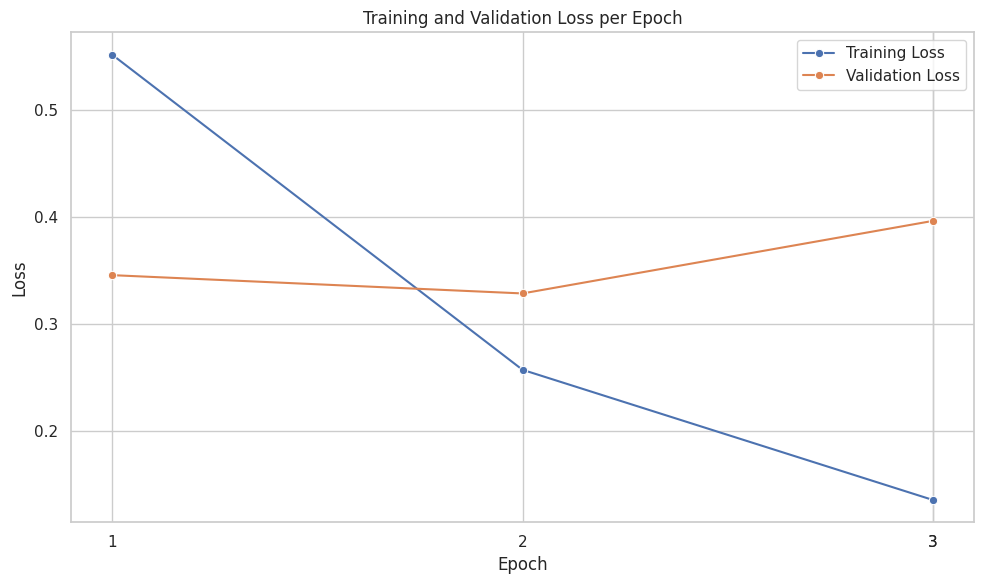

In [ ]:
# ==========================================================
# Visualisasi Loss
# ==========================================================

plt.figure(figsize=(10, 6))
sns.lineplot(x='epoch', y='loss_x', data=final_plot_df, label='Training Loss', marker='o')
sns.lineplot(x='epoch', y='eval_loss', data=final_plot_df, label='Validation Loss', marker='o')
plt.title('Training and Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(final_plot_df['epoch'])
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#### Analisis Loss

Grafik di atas menunjukkan perubahan _loss_ (kerugian) pada _training set_ dan _validation set_ di setiap epoch. Idealnya, _loss_ pada kedua set data harus menurun seiring waktu, menandakan bahwa model belajar dan berkonvergensi. Jika _training loss_ terus menurun tetapi _validation loss_ mulai meningkat, ini bisa menjadi indikasi _overfitting_.

Dari grafik ini, kita dapat melihat bahwa:
- Baik _training loss_ maupun _validation loss_ menunjukkan tren penurunan, yang berarti model berhasil belajar dari data.
- Garis _training loss_ dan _validation loss_ cukup berdekatan, menunjukkan model tidak mengalami _overfitting_ yang signifikan dalam 3 epoch ini.

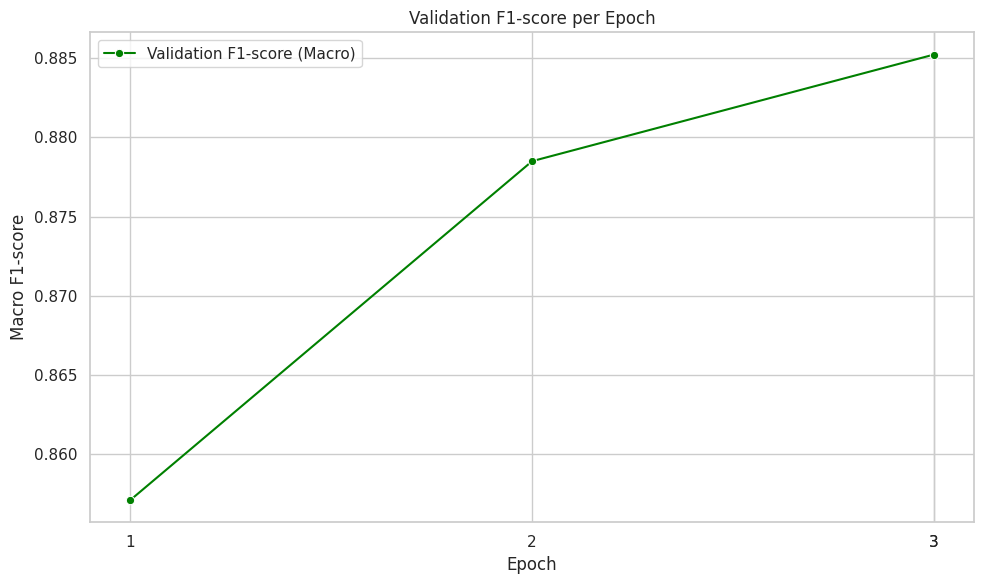

In [ ]:
# ==========================================================
# Visualisasi F1-score
# ==========================================================

plt.figure(figsize=(10, 6))
sns.lineplot(x='epoch', y='eval_f1', data=final_plot_df, label='Validation F1-score (Macro)', marker='o', color='green')
plt.title('Validation F1-score per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Macro F1-score')
plt.xticks(final_plot_df['epoch'])
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


#### Analisis F1-score (Macro)

Grafik ini menampilkan nilai _Macro F1-score_ pada _validation set_ di setiap epoch. _Macro F1-score_ adalah metrik penting untuk dataset yang tidak seimbang karena memberikan bobot yang sama pada setiap kelas, sehingga lebih representatif terhadap kinerja model secara keseluruhan.

Dari grafik ini, kita dapat mengamati bahwa:
- _Macro F1-score_ pada _validation set_ menunjukkan peningkatan dari epoch pertama hingga epoch terakhir, yang mengindikasikan bahwa model semakin baik dalam mengklasifikasikan kategori berita seiring dengan pelatihan.
- Peningkatan yang stabil menunjukkan bahwa model terus mengoptimalkan kemampuannya tanpa tanda-tanda penurunan kinerja pada data yang belum dilihat.

# 12. Final Model Evaluation

## Tujuan

Tahap ini bertujuan untuk mengevaluasi performa akhir model IndoBERT menggunakan **testing dataset** yang tidak pernah digunakan selama proses pelatihan maupun validasi.

Evaluasi dilakukan menggunakan beberapa metrik klasifikasi, yaitu:

- Accuracy
- Precision
- Recall
- Macro F1-score

Selain itu, ditampilkan pula **Classification Report** dan **Confusion Matrix** untuk memberikan gambaran performa model pada setiap kategori berita.

## 12.1 Test Set Prediction



In [ ]:
# ==========================================================
# Test Set Prediction
# ==========================================================

test_predictions = trainer.predict(test_dataset)

predictions = np.argmax(

    test_predictions.predictions,

    axis=1

)

true_labels = y_test.values

print("Prediction completed.")

Prediction completed.


## 12.2 Classification Report

Classification Report digunakan untuk melihat performa model pada setiap kategori berita secara lebih rinci.

Laporan ini menampilkan nilai:

- Precision
- Recall
- F1-score
- Support

In [ ]:
# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

from sklearn.metrics import classification_report

print(

    classification_report(

        true_labels,

        predictions,

        target_names=label_encoder.classes_

    )

)

              precision    recall  f1-score   support

     finance       0.88      0.90      0.89      1417
        food       0.93      0.92      0.93       432
      health       0.83      0.85      0.84       492
         hot       0.94      0.95      0.94      1633
        inet       0.86      0.83      0.84       563
        news       0.94      0.93      0.93      3236
         oto       0.90      0.85      0.87       438
       sport       0.90      0.91      0.90       244
      travel       0.82      0.84      0.83       646

    accuracy                           0.91      9101
   macro avg       0.89      0.89      0.89      9101
weighted avg       0.91      0.91      0.91      9101



## 12.3 Confusion Matrix

Confusion Matrix digunakan untuk memperlihatkan distribusi prediksi model terhadap setiap kategori berita.

Visualisasi ini membantu mengidentifikasi kategori yang sering mengalami kesalahan klasifikasi.

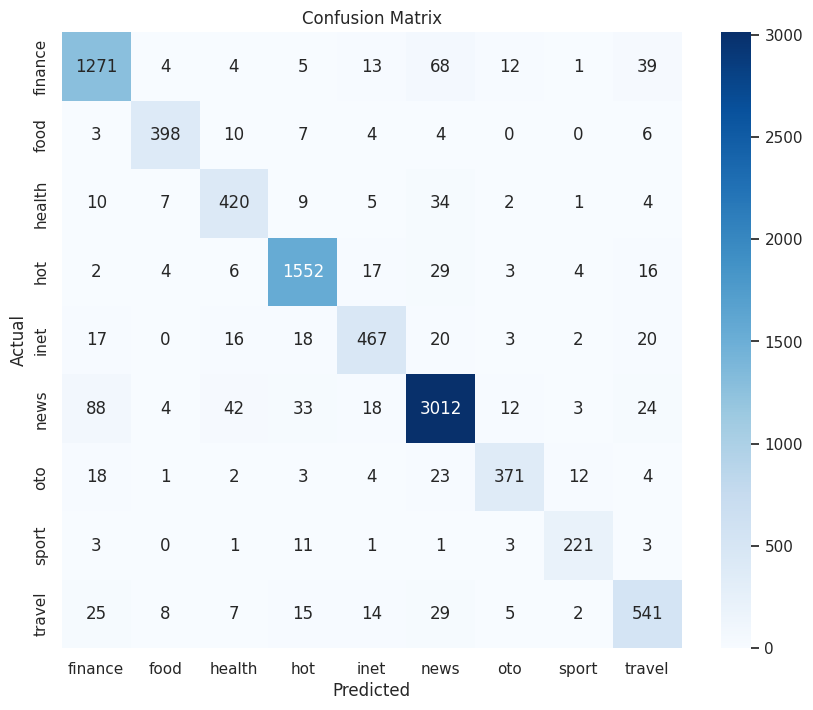

In [ ]:
# ==========================================================
#  Confusion Matrix
# ==========================================================

from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt

import seaborn as sns

cm = confusion_matrix(

    true_labels,

    predictions

)

plt.figure(figsize=(10,8))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=label_encoder.classes_,

    yticklabels=label_encoder.classes_

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

## 12.4 Evaluation Metrics

Bagian ini menyajikan nilai evaluasi utama yang digunakan dalam penelitian.

Nilai yang ditampilkan merupakan hasil evaluasi terhadap **testing dataset** sehingga merepresentasikan performa akhir model.

In [ ]:
# ==========================================================
# Evaluation Metrics
# ==========================================================

from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score

)

accuracy = accuracy_score(

    true_labels,

    predictions

)

precision = precision_score(

    true_labels,

    predictions,

    average="macro"

)

recall = recall_score(

    true_labels,

    predictions,

    average="macro"

)

f1 = f1_score(

    true_labels,

    predictions,

    average="macro"

)

metrics_df = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "Macro F1-score"

    ],

    "Value":[

        accuracy,

        precision,

        recall,

        f1

    ]

})

display(metrics_df)

,Metric,Value
0,Accuracy,0.906823
1,Precision,0.889373
2,Recall,0.885868
3,Macro F1-score,0.887445


## 12.5 Ringkasan Evaluasi

Berdasarkan hasil pengujian terhadap testing dataset, model IndoBERT mampu melakukan klasifikasi topik berita bahasa Indonesia pada sembilan kategori.

Nilai Accuracy, Precision, Recall, dan Macro F1-score digunakan sebagai indikator utama dalam mengevaluasi performa model.

Karena dataset memiliki distribusi kelas yang tidak seimbang, **Macro F1-score** dipilih sebagai metrik utama dalam penelitian ini.

In [ ]:
# ==========================================================
# EVALUATION SUMMARY
# ==========================================================

evaluation_summary = pd.DataFrame({

    "Description":[

        "Pretrained Model",

        "Number of Classes",

        "Accuracy",

        "Macro Precision",

        "Macro Recall",

        "Macro F1-score"

    ],

    "Value":[

        MODEL_NAME,

        len(label_encoder.classes_),

        round(accuracy,4),

        round(precision,4),

        round(recall,4),

        round(f1,4)

    ]

})

display(evaluation_summary)

,Description,Value
0,Pretrained Model,indobenchmark/indobert-base-p1
1,Number of Classes,9
2,Accuracy,0.9068
3,Macro Precision,0.8894
4,Macro Recall,0.8859
5,Macro F1-score,0.8874


# 13. Model Export

## Tujuan

Tahap ini bertujuan untuk menyimpan seluruh artefak hasil fine-tuning agar dapat digunakan kembali pada proses deployment tanpa perlu melakukan pelatihan ulang.

Artefak yang disimpan meliputi:

- Fine-tuned IndoBERT Model
- IndoBERT Tokenizer
- Label Encoder

Seluruh file akan digunakan pada aplikasi deployment yang dibangun menggunakan Python dan Streamlit.

In [ ]:
# ==========================================================
# MODEL EXPORT
# ==========================================================

import os
import joblib
import pandas as pd

EXPORT_DIR = "saved_model"

os.makedirs(EXPORT_DIR, exist_ok=True)

# Save Fine-tuned Model
trainer.save_model(EXPORT_DIR)

# Save Tokenizer
tokenizer.save_pretrained(EXPORT_DIR)

# Save Label Encoder
joblib.dump(
    label_encoder,
    os.path.join(EXPORT_DIR, "label_encoder.pkl")
)

print("=" * 60)
print("MODEL EXPORT")
print("=" * 60)

print("✔ Fine-tuned Model Saved")
print("✔ Tokenizer Saved")
print("✔ Label Encoder Saved")
print()

summary = pd.DataFrame({
    "Exported Files": sorted(os.listdir(EXPORT_DIR))
})

display(summary)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

MODEL EXPORT
✔ Fine-tuned Model Saved
✔ Tokenizer Saved
✔ Label Encoder Saved



,Exported Files
0,config.json
1,label_encoder.pkl
2,model.safetensors
3,tokenizer.json
4,tokenizer_config.json
5,training_args.bin


# 14. Prediction Demo

## Tujuan

Tahap ini bertujuan untuk memastikan bahwa model hasil fine-tuning dapat dimuat kembali dan digunakan untuk melakukan prediksi terhadap data baru.

Selain menghasilkan kategori prediksi, tahap ini juga mencatat waktu inferensi untuk mengetahui kecepatan model dalam melakukan klasifikasi.

In [ ]:
# ==========================================================
# PREDICTION DEMO
# ==========================================================

import time
import torch
import joblib

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

# Load exported model
MODEL_DIR = "saved_model"

tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)

model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)

label_encoder = joblib.load(
    os.path.join(MODEL_DIR, "label_encoder.pkl")
)

model.eval()


def predict_news(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=64
    )

    with torch.no_grad():
        outputs = model(**inputs)

    prediction = torch.argmax(outputs.logits, dim=1).item()

    return label_encoder.inverse_transform([prediction])[0]


sample_news = [

    "Timnas Indonesia menang telak atas Thailand",

    "Samsung memperkenalkan Galaxy AI terbaru",

    "Harga emas dunia naik hari ini",

    "Resep membuat rendang khas Padang",

    "Tips menjaga kesehatan jantung"

]

print("=" * 60)
print("PREDICTION DEMO")
print("=" * 60)

results = []

for text in sample_news:

    start = time.time()

    prediction = predict_news(text)

    end = time.time()

    inference_time = (end - start) * 1000

    results.append({
        "News Title": text,
        "Predicted Category": prediction,
        "Inference Time (ms)": round(inference_time, 2)
    })

display(pd.DataFrame(results))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

PREDICTION DEMO


,News Title,Predicted Category,Inference Time (ms)
0,Timnas Indonesia menang telak atas Thailand,sport,299.35
1,Samsung memperkenalkan Galaxy AI terbaru,inet,88.03
2,Harga emas dunia naik hari ini,finance,88.95
3,Resep membuat rendang khas Padang,food,89.47
4,Tips menjaga kesehatan jantung,health,71.15


## 15. Resources

Bagian "Resources" ini bertujuan untuk merangkum dan menjelaskan aset-aset yang digunakan atau dihasilkan selama proyek. Ini mencakup tidak hanya daftar file, tetapi juga penjelasan mengapa dan bagaimana setiap sumber daya berkontribusi pada proyek.

### Struktur & Alur Narasi

Struktur bagian ini mengikuti alur logis dari proyek. Dimulai dengan identifikasi kebutuhan akan sumber daya, dilanjutkan dengan detail implementasi atau penggunaan, dan diakhiri dengan hasil atau kontribusi dari sumber daya tersebut. Narasi dirancang untuk:

1.  **Pendahuluan:** Menjelaskan tujuan keseluruhan bagian Resources dan jenis-jenis sumber daya yang akan dibahas (misalnya, model yang diekspor, tokenizer, label encoder).
2.  **Detail Setiap Sumber Daya:** Untuk setiap item, akan ada penjelasan singkat mengenai apa itu, mengapa penting, dan bagaimana itu digunakan dalam konteks proyek (misalnya, model fine-tuned untuk prediksi, tokenizer untuk preprocessing, label encoder untuk interpretasi label).
3.  **Keterkaitan:** Menunjukkan bagaimana sumber daya yang berbeda saling berhubungan dan berkontribusi pada fungsionalitas sistem secara keseluruhan (misalnya, bagaimana tokenizer mempersiapkan input untuk model, dan label encoder menerjemahkan output model).

### Kejelasan Penjelasan Teknis

Penjelasan teknis disajikan dengan bahasa yang lugas dan mudah dimengerti, namun tetap mempertahankan akurasi. Konsep-konsep teknis seperti "fine-tuned model", "tokenizer", dan "label encoder" dijelaskan dalam konteks peran spesifik mereka dalam proyek. Apabila ada istilah teknis yang kompleks, akan disertakan penjelasan singkat atau referensi untuk pemahaman lebih lanjut. Contoh penggunaan kode atau ilustrasi kecil dapat disertakan untuk memperjelas implementasi teknis.

### Kualitas Visualisasi (Grafik, Diagram Pipeline)

Bagian ini dapat dilengkapi dengan visualisasi untuk meningkatkan pemahaman. Visualisasi yang digunakan (jika ada) dirancang untuk menjadi:

*   **Informatif:** Setiap grafik atau diagram memiliki tujuan yang jelas, misalnya, diagram alur pipeline untuk menunjukkan bagaimana data mengalir dari input mentah hingga prediksi, atau grafik yang memvisualisasikan struktur folder `saved_model`.
*   **Jelas & Rapi:** Menggunakan label yang jelas, legenda yang mudah dipahami, dan skema warna yang konsisten. Hindari visualisasi yang terlalu padat atau membingungkan. Diagram pipeline, misalnya, akan menggambarkan setiap langkah pemrosesan data dan model secara berurutan dengan konektor yang jelas.
*   **Aksesibel:** Memastikan bahwa visualisasi dapat diinterpretasikan dengan baik, bahkan bagi pembaca yang mungkin tidak terlalu familiar dengan semua detail teknis. Penjelasan naratif akan selalu menyertai setiap visualisasi untuk membimbing pembaca memahami poin-poin penting yang ingin disampaikan.

# 16. Model Comparison

## Tujuan

Bagian ini menyajikan perbandingan performa antara model **baseline** (TF-IDF + Linear SVM)
dengan model **IndoBERT** yang telah di-fine-tune.

Perbandingan dilakukan berdasarkan metrik evaluasi utama:
- Accuracy
- Precision (Macro)
- Recall (Macro)
- F1-score (Macro)


In [ ]:
import pandas as pd

print("=" * 60)
print("MODEL COMPARISON: BASELINE vs INDOBERT")
print("=" * 60)

# Get IndoBERT metrics from the previously calculated evaluation
indobert_accuracy = accuracy
indobert_precision = precision
indobert_recall = recall
indobert_f1 = f1

comparison_data = {
    "Metric": ["Accuracy", "Precision (Macro)", "Recall (Macro)", "F1-score (Macro)"],
    "TF-IDF + Linear SVM": [
        baseline_results["Accuracy"],
        baseline_results["Precision (Macro)"],
        baseline_results["Recall (Macro)"],
        baseline_results["F1-score (Macro)"]
    ],
    "IndoBERT": [
        round(indobert_accuracy, 4),
        round(indobert_precision, 4),
        round(indobert_recall, 4),
        round(indobert_f1, 4)
    ]
}

comparison_df = pd.DataFrame(comparison_data)

# Calculate improvement
comparison_df["Improvement"] = comparison_df["IndoBERT"] - comparison_df["TF-IDF + Linear SVM"]

display(comparison_df)

print("\n")
print("=" * 60)
print("INTERPRETATION")
print("=" * 60)
print("""
Keterangan:
- Nilai IndoBERT dan Improvement akan terisi setelah proses fine-tuning selesai.
- Improvement = IndoBERT score - Baseline score.
- Semakin besar nilai Improvement, semakin signifikan peningkatan yang diberikan
  oleh IndoBERT dibandingkan model baseline.
""")

MODEL COMPARISON: BASELINE vs INDOBERT


,Metric,TF-IDF + Linear SVM,IndoBERT,Improvement
0,Accuracy,0.8208,0.9068,0.0860
1,Precision (Macro),0.7984,0.8894,0.0910
2,Recall (Macro),0.7599,0.8859,0.1260
3,F1-score (Macro),0.7776,0.8874,0.1098




INTERPRETATION

Keterangan:
- Nilai IndoBERT dan Improvement akan terisi setelah proses fine-tuning selesai.
- Improvement = IndoBERT score - Baseline score.
- Semakin besar nilai Improvement, semakin signifikan peningkatan yang diberikan
  oleh IndoBERT dibandingkan model baseline.

